# Positional Encoding from Scratch

Self-attention is permutation-equivariant — without positional encoding, the model cannot distinguish *"The CEO announced"* from *"announced CEO The"*. This notebook implements every major PE scheme from scratch:

$$\text{PE injects position so that } f(x_i) \neq f(x_j) \text{ when } i \neq j$$

| Section | Scheme | Where it injects | Key property |
|---------|--------|------------------|--------------|
| §1 | Sinusoidal PE | Input embeddings | Fixed, deterministic |
| §2 | Learned PE | Input embeddings | Trainable, fixed max length |
| §3 | Relative PE (Shaw et al.) | Attention scores | Distance-based, clipped |
| §4 | ALiBi | Attention scores | Linear penalty, zero parameters |
| §5 | RoPE | Q/K vectors | Rotation, relative from dot product |
| §6 | NoPE | Nowhere | Causal mask provides implicit position |

Running example: *"The CEO announced record earnings on Friday"* — 7 tokens, `d_model = 64`.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)

## §1 — Sinusoidal Positional Encoding

$$\text{PE}(\text{pos}, 2k) = \sin\!\left(\frac{\text{pos}}{10000^{2k/d_{\text{model}}}}\right), \quad \text{PE}(\text{pos}, 2k{+}1) = \cos\!\left(\frac{\text{pos}}{10000^{2k/d_{\text{model}}}}\right)$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| pos | scalar | Token position in the sequence |
| 2k, 2k+1 | scalar | Even/odd dimension indices |
| PE | $(\text{max\_len},\, d_{\text{model}})$ | Precomputed position matrix |

> Each row is a unique fingerprint. Low-$k$ dimensions oscillate fast (local position); high-$k$ dimensions oscillate slow (coarse position).

In [2]:
class SinusoidalPE(nn.Module):
    """
    Sinusoidal Positional Encoding (Vaswani et al., 2017).

    PE(pos, 2k)   = sin(pos / 10000^(2k / d_model))
    PE(pos, 2k+1) = cos(pos / 10000^(2k / d_model))

    Args:
        d_model:  Embedding dimension.
        max_len:  Maximum sequence length to precompute.
        dropout:  Dropout rate applied after adding PE.
    """

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)                       # [max_len, d_model]
        position = torch.arange(0, max_len).unsqueeze(1).float() # [max_len, 1]
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        )                                                         # [d_model/2]

        pe[:, 0::2] = torch.sin(position * div_term)  # even dims
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims
        pe = pe.unsqueeze(0)                           # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input embeddings, shape [batch, seq_len, d_model].
        Returns:
            Position-encoded embeddings, same shape as x.
        """
        x = x + self.pe[:, :x.size(1)]  # [batch, seq_len, d_model]
        return self.dropout(x)

In [3]:
# ── shape check ──────────────────────────────────────────────────────────────
B, T, d_model = 2, 7, 64
x = torch.randn(B, T, d_model)

sinusoidal_pe = SinusoidalPE(d_model=d_model, max_len=128, dropout=0.0)
out = sinusoidal_pe(x)

print(f"Input:  {x.shape}")    # [2, 7, 64]
print(f"Output: {out.shape}")  # [2, 7, 64] — same shape, position added
assert out.shape == x.shape

# Verify PE is added (output differs from input)
assert not torch.allclose(out, x)
print("PE added successfully — output differs from input.")

Input:  torch.Size([2, 7, 64])
Output: torch.Size([2, 7, 64])
PE added successfully — output differs from input.


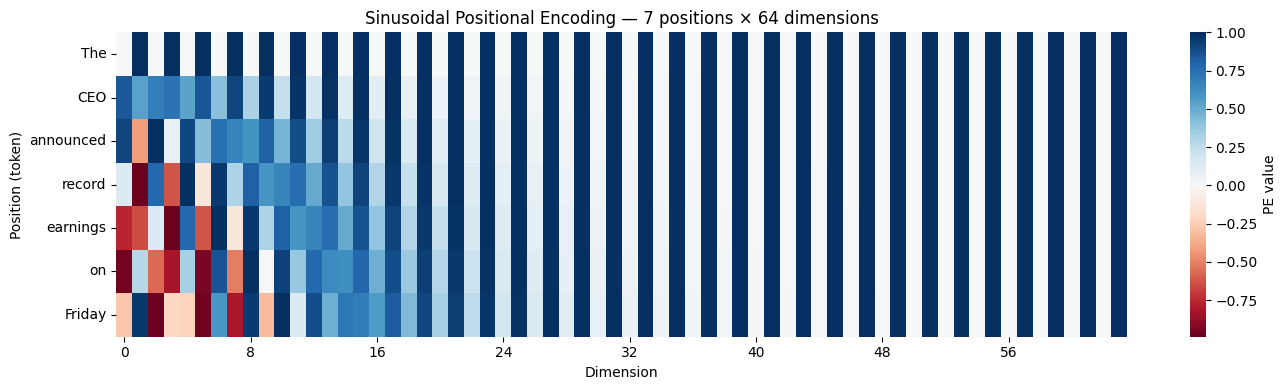

Wavelength at k=0 (dim 0-1):   6.3 positions
Wavelength at k=31 (dim 62-63): 47117 positions


In [4]:
# ── visualize the PE matrix ──────────────────────────────────────────────────
pe_matrix = sinusoidal_pe.pe[0, :7, :].numpy()  # [7, 64]
tokens = ["The", "CEO", "announced", "record", "earnings", "on", "Friday"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pe_matrix, cmap="RdBu", center=0, ax=ax,
    xticklabels=8, yticklabels=tokens,
    cbar_kws={"label": "PE value"}
)
ax.set_xlabel("Dimension")
ax.set_ylabel("Position (token)")
ax.set_title("Sinusoidal Positional Encoding — 7 positions × 64 dimensions")
plt.tight_layout()
plt.show()

# Wavelength at k=0: 2π * 10000^(0/64) = 2π ≈ 6.28 positions
# Wavelength at k=31: 2π * 10000^(62/64) ≈ 55,700 positions
wl_0 = 2 * math.pi * (10000 ** (0 / d_model))
wl_31 = 2 * math.pi * (10000 ** (62 / d_model))
print(f"Wavelength at k=0 (dim 0-1):   {wl_0:.1f} positions")
print(f"Wavelength at k=31 (dim 62-63): {wl_31:.0f} positions")

## §2 — Learned Positional Embedding

Replace sinusoids with a trainable `nn.Embedding` lookup table.

| Symbol | Shape | Description |
|--------|-------|-------------|
| PE.weight | $(\text{max\_len},\, d_{\text{model}})$ | Learned position vectors |
| positions | $(\text{seq\_len},)$ | `[0, 1, ..., T-1]` |

> **Gotcha:** Cannot extrapolate past `max_len` — position 1025 has no embedding if `max_len = 1024`.

In [5]:
class LearnedPE(nn.Module):
    """
    Learned Positional Embedding (GPT-2, BERT).

    Each position gets a trainable d_model-dimensional vector.

    Args:
        d_model:  Embedding dimension.
        max_len:  Maximum sequence length (hard ceiling).
        dropout:  Dropout rate applied after adding PE.
    """

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input embeddings, shape [batch, seq_len, d_model].
        Returns:
            Position-encoded embeddings, same shape as x.
        """
        T = x.size(1)
        positions = torch.arange(T, device=x.device)   # [seq_len]
        pe = self.embedding(positions)                   # [seq_len, d_model]
        return self.dropout(x + pe)

In [6]:
# ── shape check ──────────────────────────────────────────────────────────────
learned_pe = LearnedPE(d_model=64, max_len=512, dropout=0.0)
out = learned_pe(x)
print(f"Input:  {x.shape}")    # [2, 7, 64]
print(f"Output: {out.shape}")  # [2, 7, 64]
print(f"Learned PE params: {learned_pe.embedding.weight.shape}")  # [512, 64]
assert out.shape == x.shape

Input:  torch.Size([2, 7, 64])
Output: torch.Size([2, 7, 64])
Learned PE params: torch.Size([512, 64])


## §3 — Relative Position Attention (Shaw et al., 2018)

Instead of adding PE to the input, inject relative position directly into the attention score:

$$\text{score}(i, j) = q_i^\top k_j + q_i^\top a_{\text{clip}(j-i,\, -K,\, K)}$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| $a_{\text{rel}}$ | $(2K{+}1,\, d_k)$ | Learned embedding per relative distance |
| $K$ | scalar | Maximum clipping distance |
| bias | $(\text{seq\_len},\, \text{seq\_len})$ | Relative position bias matrix |

> Positions beyond $K$ are clipped — "10 tokens away" and "15 tokens away" get the same embedding.

In [7]:
class RelativePositionAttention(nn.Module):
    """
    Self-Attention with Relative Position Representations (Shaw et al., NAACL 2018).

    score(i, j) = q_i @ k_j + q_i @ a_{clip(j-i, -K, K)}

    Args:
        d_model:  Input embedding dimension.
        n_heads:  Number of attention heads.
        max_rel_dist: Maximum relative distance K (positions clipped to [-K, K]).
    """

    def __init__(self, d_model: int, n_heads: int, max_rel_dist: int = 16):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.max_rel_dist = max_rel_dist

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        # Learned relative position embeddings: 2K+1 entries
        num_rel = 2 * max_rel_dist + 1
        self.rel_embed = nn.Embedding(num_rel, self.d_k)  # [2K+1, d_k]

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # [B, h, T, d_k]
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # Content-based scores: Q @ K.T
        content_scores = torch.matmul(Q, K.transpose(-2, -1))  # [B, h, T, T]

        # Relative position bias: Q @ a_{clip(j-i, -K, K)}
        rel_indices = self._relative_indices(T, x.device)      # [T, T]
        rel_embeds = self.rel_embed(rel_indices)                # [T, T, d_k]
        # Q: [B, h, T, d_k], rel_embeds: [T, T, d_k] -> einsum
        rel_scores = torch.einsum("bhid,ijd->bhij", Q, rel_embeds)  # [B, h, T, T]

        scores = (content_scores + rel_scores) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), float("-inf"))

        weights = F.softmax(scores, dim=-1)             # [B, h, T, T]
        context = torch.matmul(weights, V)               # [B, h, T, d_k]
        context = context.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(context), weights

    def _relative_indices(self, T: int, device: torch.device) -> torch.Tensor:
        """Build [T, T] matrix of clipped relative position indices shifted to [0, 2K]."""
        positions = torch.arange(T, device=device)
        rel = positions.unsqueeze(0) - positions.unsqueeze(1)  # [T, T]: j - i
        rel = rel.clamp(-self.max_rel_dist, self.max_rel_dist)
        return rel + self.max_rel_dist  # shift to [0, 2K] for embedding lookup

In [8]:
# ── shape check ──────────────────────────────────────────────────────────────
B, T, d_model, n_heads = 2, 7, 64, 4
x = torch.randn(B, T, d_model)

rel_attn = RelativePositionAttention(d_model=d_model, n_heads=n_heads, max_rel_dist=3)
out, weights = rel_attn(x)

print(f"Input:   {x.shape}")       # [2, 7, 64]
print(f"Output:  {out.shape}")     # [2, 7, 64]
print(f"Weights: {weights.shape}") # [2, 4, 7, 7]
print(f"Rel embed table: {rel_attn.rel_embed.weight.shape}")  # [7, 16] — 2*3+1=7 entries

# Show the clipped relative position matrix
tokens = ["The", "CEO", "ann", "rec", "ear", "on", "Fri"]
rel_idx = rel_attn._relative_indices(T, x.device) - rel_attn.max_rel_dist
print(f"\nRelative position matrix (K=3, clipped):")
print(rel_idx.numpy())

Input:   torch.Size([2, 7, 64])
Output:  torch.Size([2, 7, 64])
Weights: torch.Size([2, 4, 7, 7])
Rel embed table: torch.Size([7, 16])

Relative position matrix (K=3, clipped):
[[ 0  1  2  3  3  3  3]
 [-1  0  1  2  3  3  3]
 [-2 -1  0  1  2  3  3]
 [-3 -2 -1  0  1  2  3]
 [-3 -3 -2 -1  0  1  2]
 [-3 -3 -3 -2 -1  0  1]
 [-3 -3 -3 -3 -2 -1  0]]


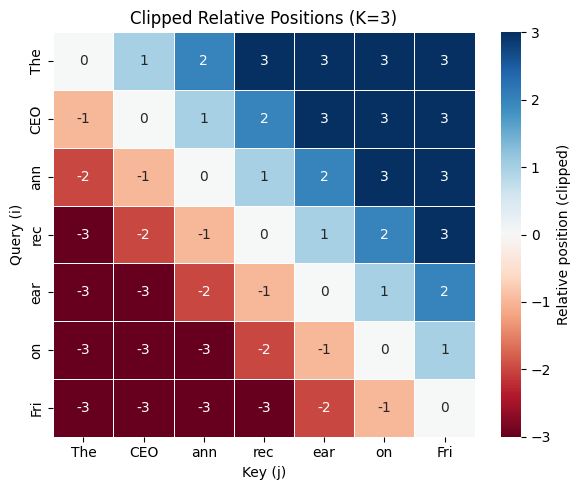

Diagonal = 0 (self-attention). Values clipped to [-3, 3].
Only 7 unique embeddings needed.


In [9]:
# ── visualize clipped relative position matrix ───────────────────────────────
tokens = ["The", "CEO", "ann", "rec", "ear", "on", "Fri"]
rel_matrix = rel_attn._relative_indices(T, x.device) - rel_attn.max_rel_dist  # [T, T]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    rel_matrix.numpy(), annot=True, fmt="d", cmap="RdBu", center=0, ax=ax,
    xticklabels=tokens, yticklabels=tokens,
    cbar_kws={"label": "Relative position (clipped)"},
    linewidths=0.5
)
ax.set_xlabel("Key (j)")
ax.set_ylabel("Query (i)")
ax.set_title(f"Clipped Relative Positions (K={rel_attn.max_rel_dist})")
plt.tight_layout()
plt.show()

print(f"Diagonal = 0 (self-attention). Values clipped to [-{rel_attn.max_rel_dist}, {rel_attn.max_rel_dist}].")
print(f"Only {2 * rel_attn.max_rel_dist + 1} unique embeddings needed.")

## §4 — ALiBi (Attention with Linear Biases)

$$\text{ALiBi\_score}(i, j) = q_i^\top k_j - m \cdot |i - j|$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| $m$ | $(n_{\text{heads}},)$ | Head-specific slope, geometric sequence |
| $|i - j|$ | $(\text{seq\_len},\, \text{seq\_len})$ | Toeplitz distance matrix |
| bias | $(n_{\text{heads}},\, \text{seq\_len},\, \text{seq\_len})$ | Precomputed penalty |

> Zero learned parameters. Slopes: $m_h = 2^{-8h/n}$ for $h = 1, \ldots, n$. In practice, paired with a causal mask — only the lower triangle matters.

In [10]:
class ALiBi(nn.Module):
    """
    Attention with Linear Biases (Press, Smith, Lewis — ICLR 2022).

    Subtracts a fixed linear penalty m * |i - j| from attention scores.
    No learned position parameters.

    Args:
        d_model:  Input embedding dimension.
        n_heads:  Number of attention heads.
        max_len:  Maximum sequence length for precomputing the distance matrix.
    """

    def __init__(self, d_model: int, n_heads: int, max_len: int = 2048):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        # Slopes: geometric sequence 2^(-8/n), 2^(-16/n), ..., 2^(-8)
        slopes = self._get_slopes(n_heads)                       # [n_heads]
        self.register_buffer("slopes", slopes)

        # Toeplitz distance matrix: distances[i,j] = |i - j|
        positions = torch.arange(max_len)
        distances = (positions.unsqueeze(0) - positions.unsqueeze(1)).abs().float()
        self.register_buffer("distances", distances)             # [max_len, max_len]

    @staticmethod
    def _get_slopes(n_heads: int) -> torch.Tensor:
        """Geometric slopes: 2^(-8*h/n) for h = 1, ..., n."""
        return torch.tensor(
            [2 ** (-8 * h / n_heads) for h in range(1, n_heads + 1)]
        )  # [n_heads]

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # [B, h, T, d_k]
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # Content scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # [B, h, T, T]

        # ALiBi bias: slopes[h] * distances[i,j]
        alibi_bias = -self.slopes.view(1, self.n_heads, 1, 1) * self.distances[:T, :T].unsqueeze(0).unsqueeze(0)
        scores = scores + alibi_bias  # [B, h, T, T]

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), float("-inf"))

        weights = F.softmax(scores, dim=-1)             # [B, h, T, T]
        context = torch.matmul(weights, V)               # [B, h, T, d_k]
        context = context.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(context), weights

In [11]:
# ── shape check ──────────────────────────────────────────────────────────────
B, T, d_model, n_heads = 2, 7, 64, 8
x = torch.randn(B, T, d_model)

alibi = ALiBi(d_model=d_model, n_heads=n_heads)
causal_mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
out, weights = alibi(x, mask=causal_mask)

print(f"Input:   {x.shape}")       # [2, 7, 64]
print(f"Output:  {out.shape}")     # [2, 7, 64]
print(f"Weights: {weights.shape}") # [2, 8, 7, 7]
print(f"\nSlopes: {alibi.slopes.tolist()}")
print(f"Slopes (fractions): {[f'1/{int(1/s)}' for s in alibi.slopes.tolist()]}")

Input:   torch.Size([2, 7, 64])
Output:  torch.Size([2, 7, 64])
Weights: torch.Size([2, 8, 7, 7])

Slopes: [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625]
Slopes (fractions): ['1/2', '1/4', '1/8', '1/16', '1/32', '1/64', '1/128', '1/256']


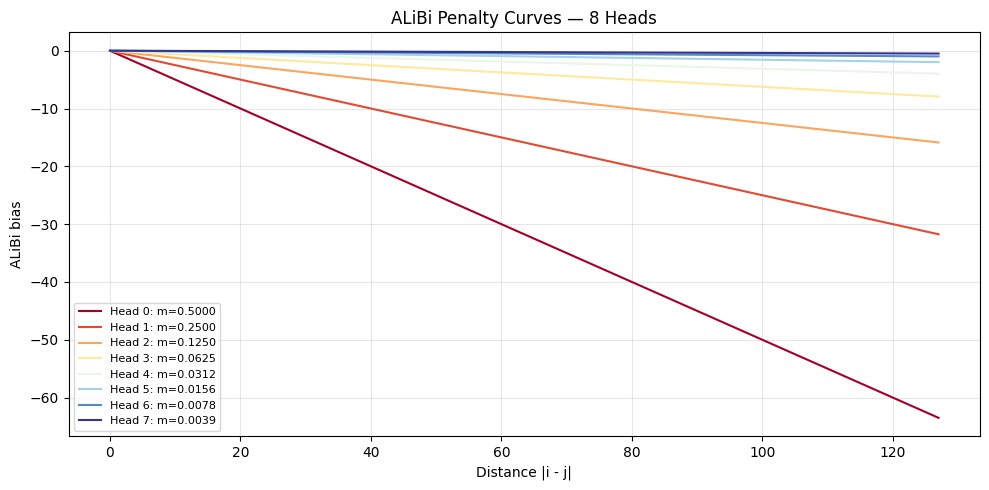

In [12]:
# ── visualize ALiBi penalty curves ────────────────────────────────────────────
distances = torch.arange(128).float()
slopes = ALiBi._get_slopes(8)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlBu(np.linspace(0, 1, 8))
for h in range(8):
    penalty = -slopes[h] * distances
    ax.plot(distances.numpy(), penalty.numpy(), color=colors[h],
            label=f"Head {h}: m={slopes[h]:.4f}", linewidth=1.5)

ax.set_xlabel("Distance |i - j|")
ax.set_ylabel("ALiBi bias")
ax.set_title("ALiBi Penalty Curves — 8 Heads")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## §5 — Rotary Positional Encoding (RoPE)

Rotate each Q/K dimension pair by a position-dependent angle. The dot product of rotated vectors depends only on the *relative* distance.

$$q'_{2k} = q_{2k} \cos(\text{pos} \cdot \theta_k) - q_{2k+1} \sin(\text{pos} \cdot \theta_k)$$
$$q'_{2k+1} = q_{2k} \sin(\text{pos} \cdot \theta_k) + q_{2k+1} \cos(\text{pos} \cdot \theta_k)$$
$$\theta_k = \frac{1}{10000^{2k/d_k}}$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| $\theta_k$ | $(d_k/2,)$ | Per-pair frequency |
| cos/sin cache | $(\text{max\_len},\, d_k/2)$ | Precomputed rotation angles |
| Q, K rotated | $(B,\, h,\, T,\, d_k)$ | Position-encoded query/key vectors |

> $\text{rotate}(q, \text{pos}_q)^\top \text{rotate}(k, \text{pos}_k) = f(q, k, \text{pos}_q - \text{pos}_k)$ — relative position from absolute rotation.

In [13]:
class RotaryPE(nn.Module):
    """
    Rotary Positional Encoding (Su et al., 2021).

    Rotates pairs of Q/K dimensions by position-dependent angles.
    The dot product of rotated vectors encodes relative position.

    Args:
        d_k:        Dimension per head.
        max_len:    Maximum sequence length to precompute.
        theta_base: Base frequency (10000 for standard, higher for long context).
    """

    def __init__(self, d_k: int, max_len: int = 4096, theta_base: float = 10000.0):
        super().__init__()
        self.d_k = d_k

        # Frequencies: θ_k = 1 / theta_base^(2k / d_k) for k = 0, ..., d_k/2 - 1
        freqs = 1.0 / (theta_base ** (torch.arange(0, d_k, 2).float() / d_k))  # [d_k/2]
        positions = torch.arange(max_len).float()                                # [max_len]
        angles = torch.outer(positions, freqs)                                   # [max_len, d_k/2]

        self.register_buffer("cos_cached", angles.cos())  # [max_len, d_k/2]
        self.register_buffer("sin_cached", angles.sin())  # [max_len, d_k/2]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply rotary encoding to Q or K.

        Args:
            x: Tensor of shape [batch, n_heads, seq_len, d_k].
        Returns:
            Rotated tensor, same shape.
        """
        T = x.size(2)
        cos = self.cos_cached[:T].unsqueeze(0).unsqueeze(0)  # [1, 1, T, d_k/2]
        sin = self.sin_cached[:T].unsqueeze(0).unsqueeze(0)  # [1, 1, T, d_k/2]

        # Split into pairs and rotate (the "rotate_half" trick)
        x_even = x[..., 0::2]  # [B, h, T, d_k/2]
        x_odd  = x[..., 1::2]  # [B, h, T, d_k/2]

        # 2D rotation: [cos -sin; sin cos] @ [x_even; x_odd]
        rotated_even = x_even * cos - x_odd * sin
        rotated_odd  = x_even * sin + x_odd * cos

        # Interleave back: [r_even_0, r_odd_0, r_even_1, r_odd_1, ...]
        return torch.stack([rotated_even, rotated_odd], dim=-1).flatten(-2)

In [14]:
class RoPEAttention(nn.Module):
    """
    Multi-head attention with Rotary Positional Encoding.

    Args:
        d_model:    Input embedding dimension.
        n_heads:    Number of attention heads.
        theta_base: RoPE base frequency.
    """

    def __init__(self, d_model: int, n_heads: int, theta_base: float = 10000.0):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.rope = RotaryPE(self.d_k, theta_base=theta_base)

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # [B, h, T, d_k]
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # Apply RoPE to Q and K (not V)
        Q = self.rope(Q)  # [B, h, T, d_k]
        K = self.rope(K)  # [B, h, T, d_k]

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), float("-inf"))

        weights = F.softmax(scores, dim=-1)
        context = torch.matmul(weights, V)
        context = context.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(context), weights

In [15]:
# ── shape check ──────────────────────────────────────────────────────────────
B, T, d_model, n_heads = 2, 7, 64, 4
x = torch.randn(B, T, d_model)

rope_attn = RoPEAttention(d_model=d_model, n_heads=n_heads)
out, weights = rope_attn(x)

print(f"Input:   {x.shape}")       # [2, 7, 64]
print(f"Output:  {out.shape}")     # [2, 7, 64]
print(f"Weights: {weights.shape}") # [2, 4, 7, 7]
assert out.shape == x.shape

Input:   torch.Size([2, 7, 64])
Output:  torch.Size([2, 7, 64])
Weights: torch.Size([2, 4, 7, 7])


In [16]:
# ── verify relative position property ────────────────────────────────────────
# The dot product of rotated Q and K should depend only on (pos_q - pos_k).
# Test: rotate same vector at positions (1, 3) and (5, 7) — same distance of 2.

d_k = 16
rope = RotaryPE(d_k=d_k)

q_vec = torch.randn(1, 1, 1, d_k).expand(1, 1, 8, d_k)  # same vector at 8 positions
k_vec = torch.randn(1, 1, 1, d_k).expand(1, 1, 8, d_k)

q_rot = rope(q_vec)  # [1, 1, 8, d_k]
k_rot = rope(k_vec)  # [1, 1, 8, d_k]

# dot(q@pos1, k@pos3) should equal dot(q@pos5, k@pos7) — both distance 2
dot_1_3 = (q_rot[0, 0, 1] * k_rot[0, 0, 3]).sum()
dot_5_7 = (q_rot[0, 0, 5] * k_rot[0, 0, 7]).sum()

print(f"dot(q@pos1, k@pos3) = {dot_1_3.item():.6f}")
print(f"dot(q@pos5, k@pos7) = {dot_5_7.item():.6f}")
print(f"Difference: {abs(dot_1_3 - dot_5_7).item():.2e}")
assert torch.allclose(dot_1_3, dot_5_7, atol=1e-5)
print("\nRelative position property verified — same distance = same dot product.")

dot(q@pos1, k@pos3) = 3.366882
dot(q@pos5, k@pos7) = 3.366882
Difference: 2.38e-07

Relative position property verified — same distance = same dot product.


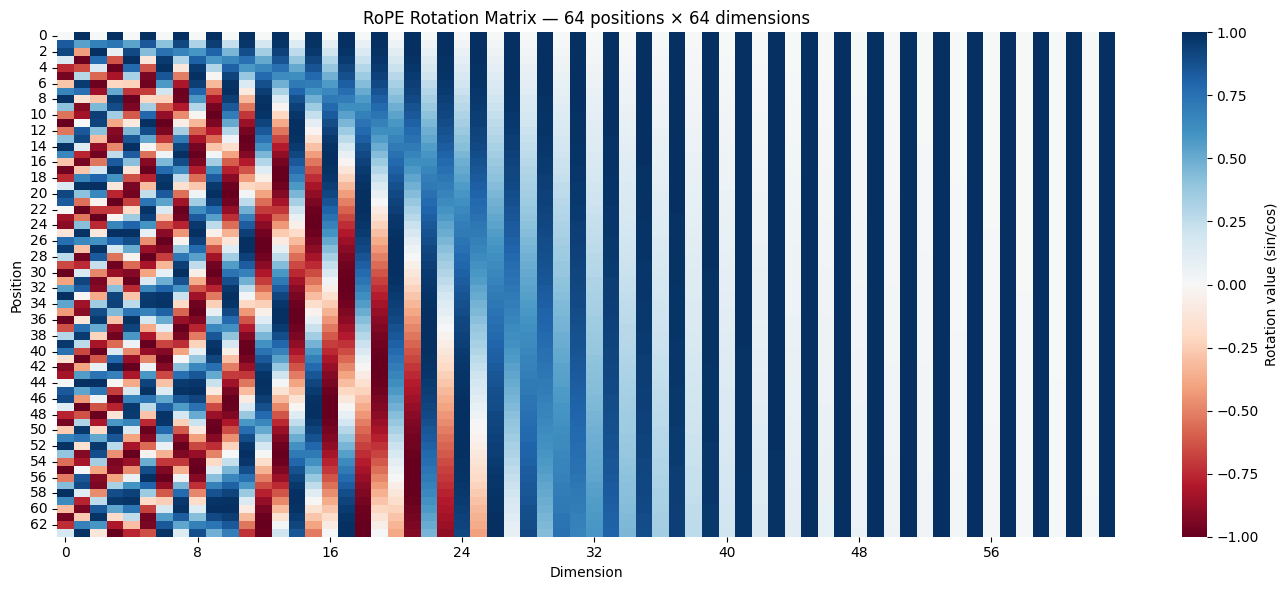

Left dims oscillate fast (position-encoding band) — right dims barely change (semantic band).
Pair k=0: 1.0000 rad/pos (completes a cycle every ~6 positions)
Pair k=31: 0.000133 rad/pos (cycle length: ~47117 positions)
Ratio: 7499x faster rotation at k=0 vs k=31


In [17]:
# ── visualize RoPE rotation angles (two-band structure) ──────────────────────
# Show the cos component of RoPE — same style as the sinusoidal PE heatmap in §1.
# Rows = positions, columns = dimension pairs. Left pairs rotate fast, right pairs barely move.
T_viz, d_k_viz = 64, 64
freqs = 1.0 / (10000 ** (torch.arange(0, d_k_viz, 2).float() / d_k_viz))  # [d_k/2]
angles = torch.outer(torch.arange(T_viz).float(), freqs)                    # [T_viz, d_k/2]

# Build the full [T_viz, d_k] matrix interleaving sin/cos — same layout as sinusoidal PE
rope_matrix = torch.zeros(T_viz, d_k_viz)
rope_matrix[:, 0::2] = angles.sin()  # even dims: sin component
rope_matrix[:, 1::2] = angles.cos()  # odd dims: cos component

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    rope_matrix.numpy(), cmap="RdBu", center=0, ax=ax,
    xticklabels=8,
    cbar_kws={"label": "Rotation value (sin/cos)"},
)
ax.set_xlabel("Dimension")
ax.set_ylabel("Position")
ax.set_title("RoPE Rotation Matrix — 64 positions × 64 dimensions")
plt.tight_layout()
plt.show()

print(f"Left dims oscillate fast (position-encoding band) — right dims barely change (semantic band).")
print(f"Pair k=0: {angles[1, 0]:.4f} rad/pos (completes a cycle every ~{2 * 3.14159 / angles[1, 0]:.0f} positions)")
print(f"Pair k={d_k_viz//2-1}: {angles[1, -1]:.6f} rad/pos (cycle length: ~{2 * 3.14159 / angles[1, -1]:.0f} positions)")
print(f"Ratio: {angles[1, 0] / angles[1, -1]:.0f}x faster rotation at k=0 vs k={d_k_viz//2-1}")

## Bonus: p-RoPE Band Visualization

p-RoPE (Proportional RoPE) — used in Gemma 4 — applies RoPE to only a fraction `p` of dimension pairs and freezes the rest. With `p=0.25` and `d_k=128` (Gemma 4 global layers), only 16 of 64 pairs rotate; the other 48 pairs become pure semantic channels with no rotation drift across long contexts.

$$\text{p-RoPE}(q, p) = \begin{cases} \text{rotate}(q_k, \text{pos} \cdot \theta_k) & k < \lfloor (d_k/2) \cdot p \rfloor \\ q_k & \text{otherwise} \end{cases}$$

> The visualization below shows the band structure at Gemma 4 production scale: top = standard RoPE (all 64 pairs rotated, gradient red→blue), bottom = p-RoPE (first 16 pairs rotated, last 48 frozen).

In [ ]:
# ── visualize p-RoPE band structure (Standard RoPE vs p-RoPE) ────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Gemma 4 production values
d_k = 128
n_pairs = d_k // 2          # 64 pairs
theta_base = 1_000_000.0    # Gemma 4 global layers use base 1M
p = 0.25
n_rotated = int(n_pairs * p)  # 16 pairs receive RoPE

freqs = 1.0 / (theta_base ** (np.arange(0, d_k, 2) / d_k))
log_freqs = np.log10(freqs)

cmap = plt.cm.RdYlBu_r
norm = Normalize(vmin=log_freqs.min(), vmax=log_freqs.max())
colors = cmap(norm(log_freqs))

fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(3, 1, height_ratios=[0.1, 1, 1], hspace=1.5, top=0.94, bottom=0.04)
cax = fig.add_subplot(gs[0])
ax_top = fig.add_subplot(gs[1])
ax_bot = fig.add_subplot(gs[2])

cell_w = 0.18
cell_h = 1.0
gray = "#cccccc"
gray_edge = "#888888"

def draw_chain(ax, pair_colors, frozen_mask, title, label_positions):
    for i in range(n_pairs):
        if frozen_mask[i]:
            face, edge = gray, gray_edge
        else:
            face, edge = pair_colors[i], pair_colors[i]
        rect = mpatches.Rectangle((i * cell_w, 0), cell_w, cell_h,
                                   facecolor=face, edgecolor=edge, linewidth=0.5)
        ax.add_patch(rect)
    # P labels ABOVE the cells (clears bracket annotations below)
    for tp in label_positions:
        x = tp * cell_w + cell_w/2
        ax.plot([x, x], [cell_h + 0.05, cell_h + 0.18], color="black", lw=1)
        ax.text(x, cell_h + 0.28, f"P{tp}", ha="center", va="bottom", fontsize=9)
    ax.set_xlim(-0.3, n_pairs * cell_w + 0.1)
    ax.set_ylim(-1.3, 1.8)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=8)
    ax.axis("off")

# top: Standard RoPE (all 64 pairs rotated)
draw_chain(ax_top, colors, [False] * n_pairs,
           f"Standard RoPE — d_k = {d_k}, all {n_pairs} pairs rotated",
           label_positions=[0, n_pairs - 1])
ax_top.text(cell_w * 4, -0.55, "fast rotation\n(local position)",
            ha="center", va="top", fontsize=9, color="#b00020", fontweight="bold")
ax_top.text((n_pairs - 4) * cell_w, -0.55, "slow rotation\n(semantic, drifts at 128K+)",
            ha="center", va="top", fontsize=9, color="#1f4e79", fontweight="bold")

# bottom: p-RoPE (16 rotated, 48 frozen)
frozen = [i >= n_rotated for i in range(n_pairs)]
draw_chain(ax_bot, colors, frozen,
           f"p-RoPE — p = {p}, only {n_rotated} of {n_pairs} pairs rotated",
           label_positions=[0, n_rotated, n_pairs - 1])

mid_rotated_x = n_rotated * cell_w / 2
mid_frozen_x = n_rotated * cell_w + (n_pairs - n_rotated) * cell_w / 2

ax_bot.annotate("", xy=(0, -0.25), xytext=(n_rotated * cell_w, -0.25),
                arrowprops=dict(arrowstyle="|-|", color="#b00020", lw=1.5))
ax_bot.text(mid_rotated_x, -0.6, f"{n_rotated} rotated\n(positional)",
            ha="center", va="top", fontsize=9, color="#b00020", fontweight="bold")

ax_bot.annotate("", xy=(n_rotated * cell_w, -0.25),
                xytext=(n_pairs * cell_w, -0.25),
                arrowprops=dict(arrowstyle="|-|", color="#444", lw=1.5))
ax_bot.text(mid_frozen_x, -0.6, f"{n_pairs - n_rotated} frozen — no rotation\n(pure semantic, no drift)",
            ha="center", va="top", fontsize=9, color="#444", fontweight="bold")

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Rotation speed: log10(θ_k)  —  red = fast, blue = slow", fontsize=9, labelpad=4)
cbar.ax.tick_params(labelsize=8)

plt.show()

print(f"Standard RoPE: {n_pairs} pairs rotated (d_k={d_k}, theta_base={theta_base:.0e})")
print(f"p-RoPE (p={p}): {n_rotated} pairs rotated (P0..P{n_rotated-1}), {n_pairs - n_rotated} pairs frozen (P{n_rotated}..P{n_pairs-1})")

## §6 — No Positional Encoding (NoPE)

Skip all positional encoding entirely. In causal (decoder-only) transformers, the triangular attention mask implicitly encodes position: token at position $i$ can attend to exactly $i+1$ tokens.

$$x = \text{token\_embedding} \quad \text{(no PE added, no rotation, no bias)}$$

| Mechanism | Why it works |
|-----------|-------------|
| Predecessor counting | Token $i$ attends to $i+1$ tokens — unique "shape" per position |
| Embedding similarity gradient | Nearby tokens develop higher similarity than distant ones |

> **Decoder-only.** Bidirectional encoders see all tokens equally — no implicit position signal. NoPE fails for BERT-style models.

In [18]:
class NoPEAttention(nn.Module):
    """
    Causal Self-Attention with No Positional Encoding.

    Standard multi-head attention with a causal mask — no PE of any kind.
    Position information comes implicitly from the triangular mask structure.

    Args:
        d_model: Input embedding dimension.
        n_heads: Number of attention heads.
    """

    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # [B, h, T, d_k]
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # No PE: no rotation, no bias, no position embedding
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # [B, h, T, T]

        # Causal mask — the ONLY source of position information
        causal_mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=x.device), diagonal=1)
        scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float("-inf"))

        weights = F.softmax(scores, dim=-1)
        context = torch.matmul(weights, V)
        context = context.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(context), weights

In [19]:
# ── shape check ──────────────────────────────────────────────────────────────
B, T, d_model, n_heads = 2, 7, 64, 4
x = torch.randn(B, T, d_model)

nope_attn = NoPEAttention(d_model=d_model, n_heads=n_heads)
out, weights = nope_attn(x)

print(f"Input:   {x.shape}")       # [2, 7, 64]
print(f"Output:  {out.shape}")     # [2, 7, 64]
print(f"Weights: {weights.shape}") # [2, 4, 7, 7]

# Verify causal masking: upper triangle of weights must be zero
upper_tri = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
assert (weights[:, :, upper_tri] < 1e-9).all()
print("Causal mask verified — no future token leakage.")
print("No PE of any kind — position inferred from causal mask structure.")

Input:   torch.Size([2, 7, 64])
Output:  torch.Size([2, 7, 64])
Weights: torch.Size([2, 4, 7, 7])
Causal mask verified — no future token leakage.
No PE of any kind — position inferred from causal mask structure.


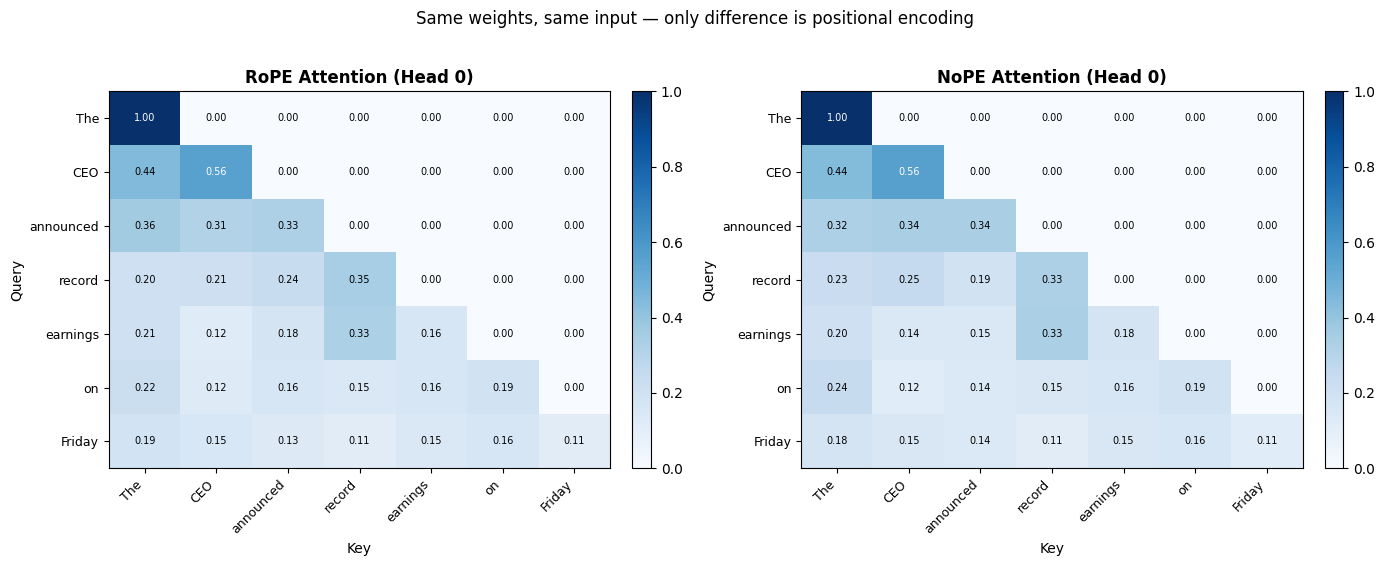

Mean absolute difference in attention weights: 0.0100
RoPE shifts attention patterns based on position; NoPE relies on content alone.


In [20]:
# ── side-by-side: RoPE vs NoPE attention weights ────────────────────────────
torch.manual_seed(42)
B, T, d_model, n_heads = 1, 7, 64, 4
x = torch.randn(B, T, d_model)
tokens = ["The", "CEO", "announced", "record", "earnings", "on", "Friday"]

# Same weights for fair comparison
rope_attn = RoPEAttention(d_model=d_model, n_heads=n_heads)
nope_attn = NoPEAttention(d_model=d_model, n_heads=n_heads)
nope_attn.W_q.weight.data = rope_attn.W_q.weight.data.clone()
nope_attn.W_k.weight.data = rope_attn.W_k.weight.data.clone()
nope_attn.W_v.weight.data = rope_attn.W_v.weight.data.clone()
nope_attn.W_o.weight.data = rope_attn.W_o.weight.data.clone()

causal_mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
_, w_rope = rope_attn(x, mask=causal_mask)
_, w_nope = nope_attn(x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, w, title in zip(axes, [w_rope, w_nope], ["RoPE Attention (Head 0)", "NoPE Attention (Head 0)"]):
    mat = w[0, 0].detach().numpy()
    im = ax.imshow(mat, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel("Key")
    ax.set_ylabel("Query")
    ax.set_title(title, fontweight="bold")
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if mat[i, j] > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Same weights, same input — only difference is positional encoding", y=1.02)
plt.tight_layout()
plt.show()

diff = (w_rope - w_nope).abs().mean().item()
print(f"Mean absolute difference in attention weights: {diff:.4f}")
print("RoPE shifts attention patterns based on position; NoPE relies on content alone.")

## Summary

| Scheme | Injection point | Parameters | FlashAttention | Length extrapolation |
|--------|----------------|------------|----------------|--------------------|
| Sinusoidal PE | Input | 0 | Yes | Weak |
| Learned PE | Input | max_len × d_model | Yes | None |
| Relative PE | Scores | (2K+1) × d_k per head | No | Within clip window |
| ALiBi | Scores | 0 | Partial | Good (linear) |
| RoPE | Q/K vectors | 0 | Yes | With θ scaling |
| NoPE | Nowhere | 0 | Yes | Best (decoder-only) |